# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Load CSV Dataset

In [4]:
# Load the CSV file
df = pd.read_csv(r'C:\Users\Sunrise Computer\Desktop\DecodeLabs_Internship\data\creditcard.csv')

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn names:")
print(df.columns.tolist())

✅ Data loaded successfully!
Shape: 1,200 rows × 14 columns

First 3 rows:
     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram      2853.1  
1     SAVE10       Referral       302.7  
2   FREESHIP          Email      2753.4  

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode

# Keep Only Numeric Columns

In [5]:
# Keep only numeric columns - this prevents all string errors
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols].copy()

print(f"✅ Using only numeric columns: {len(numeric_cols)} columns")
print(f"New shape: {df.shape}")
print("\nColumns being used:")
print(df.columns.tolist())

✅ Using only numeric columns: 4 columns
New shape: (1200, 4)

Columns being used:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']


# Data Information

In [6]:
print("="*60)
print("DATA INFORMATION")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe().round(2))

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

DATA INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Quantity     1200 non-null   int64  
 1   UnitPrice    1200 non-null   float64
 2   ItemsInCart  1200 non-null   int64  
 3   TotalPrice   1200 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 37.6 KB
None

STATISTICAL SUMMARY
       Quantity  UnitPrice  ItemsInCart  TotalPrice
count   1200.00    1200.00      1200.00     1200.00
mean       2.95     356.41         5.48     1053.97
std        1.41     197.18         2.28      819.86
min        1.00      11.39         1.00       11.39
25%        2.00     186.06         4.00      410.52
50%        3.00     364.21         5.00      823.62
75%        4.00     521.57         7.00     1578.48
max        5.00     699.93        10.00     3456.40

MISSING VALUES
Quantity       0
UnitPrice      0
ItemsInCart    0
TotalPrice     0
dtype: 

# Target Variable Check

In [7]:
print("="*60)
print("TARGET VARIABLE CHECK")
print("="*60)

if 'Class' in df.columns:
    print(f"Target column: 'Class'")
    print(df['Class'].value_counts())
    print(f"\nFraud rate: {df['Class'].mean():.4%}")
elif 'DEFAULT' in df.columns:
    print(f"Target column: 'DEFAULT'")
    print(df['DEFAULT'].value_counts())
    print(f"\nDefault rate: {df['DEFAULT'].mean():.2%}")
else:
    print("ℹ️ No target column found. We'll use the last column for practice.")
    target_col = df.columns[-1]
    print(f"Using '{target_col}' as target")

TARGET VARIABLE CHECK
ℹ️ No target column found. We'll use the last column for practice.
Using 'TotalPrice' as target


# Introduce Missing Data

In [8]:
np.random.seed(42)
df_missing = df.copy()

# Select columns for missing data (skip target columns)
all_cols = df.columns.tolist()
skip_cols = ['Class', 'DEFAULT']
cols_to_corrupt = [col for col in all_cols if col not in skip_cols][:3]

print(f"Adding 15% missing values to: {cols_to_corrupt}")

for col in cols_to_corrupt:
    mask = np.random.random(len(df)) < 0.15
    df_missing.loc[mask, col] = np.nan

print("\n🔴 Missing data introduced!")
for col in cols_to_corrupt:
    missing_pct = df_missing[col].isnull().mean()
    print(f"  {col:15s}: {missing_pct:.1%} missing")

Adding 15% missing values to: ['Quantity', 'UnitPrice', 'ItemsInCart']

🔴 Missing data introduced!
  Quantity       : 16.1% missing
  UnitPrice      : 16.2% missing
  ItemsInCart    : 14.6% missing


# Median Imputation

In [9]:
df_median = df_missing.copy()

for col in cols_to_corrupt:
    median_val = df_median[col].median()
    df_median[col].fillna(median_val, inplace=True)

print("✅ Median imputation complete!")
print(f"  Missing values after median: {df_median.isnull().sum().sum()}")

✅ Median imputation complete!
  Missing values after median: 562


# KNN Imputation

In [10]:
# Get columns for KNN
knn_cols = df_missing.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Class', 'DEFAULT']:
    if col in knn_cols:
        knn_cols.remove(col)

# Take first 10 columns
knn_cols = knn_cols[:10]

print(f"Using {len(knn_cols)} columns for KNN imputation")

# Prepare data
df_knn_data = df_missing[knn_cols].copy()

# Fill any missing with median first
for col in knn_cols:
    if df_knn_data[col].isnull().sum() > 0:
        df_knn_data[col].fillna(df_knn_data[col].median(), inplace=True)

# Apply KNN
imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = imputer.fit_transform(df_knn_data)

df_knn = df_missing.copy()
df_knn[knn_cols] = df_knn_imputed

print("✅ KNN imputation complete!")
print(f"  Missing values after KNN: {df_knn.isnull().sum().sum()}")

Using 4 columns for KNN imputation
✅ KNN imputation complete!
  Missing values after KNN: 0


# Compare Methods

In [11]:
print("="*60)
print("IMPUTATION COMPARISON")
print("="*60)

comparison = pd.DataFrame({
    'Feature': cols_to_corrupt,
    'Original_Var': [df[col].var() for col in cols_to_corrupt],
    'Median_Var': [df_median[col].var() for col in cols_to_corrupt],
    'KNN_Var': [df_knn[col].var() for col in cols_to_corrupt]
})

print(comparison.round(2))

print("\n" + "="*60)
print("VARIANCE PRESERVATION")
print("="*60)

median_pct = (comparison['Median_Var'] / comparison['Original_Var']).mean() * 100
knn_pct = (comparison['KNN_Var'] / comparison['Original_Var']).mean() * 100

print(f"Median: {median_pct:.1f}% variance preserved")
print(f"KNN:    {knn_pct:.1f}% variance preserved")

# Choose best method
if knn_pct >= median_pct:
    df_clean = df_knn.copy()
    print("\n✅ Using KNN imputation (better variance preservation)")
else:
    df_clean = df_median.copy()
    print("\n✅ Using Median imputation (better variance preservation)")

IMPUTATION COMPARISON
       Feature  Original_Var  Median_Var   KNN_Var
0     Quantity          1.98        2.00      1.89
1    UnitPrice      38878.83    38691.01  37485.56
2  ItemsInCart          5.21        5.28      4.84

VARIANCE PRESERVATION
Median: 100.5% variance preserved
KNN:    95.0% variance preserved

✅ Using Median imputation (better variance preservation)


# Outlier Detection

In [12]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers), len(outliers)/len(df)*100

print("="*60)
print("OUTLIER DETECTION (IQR Method)")
print("="*60)

# Select columns to check
check_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Class', 'DEFAULT']:
    if col in check_cols:
        check_cols.remove(col)
check_cols = check_cols[:5]

for col in check_cols:
    lower, upper, count, pct = detect_outliers(df_clean, col)
    print(f"{col:15s}: {count:5d} outliers ({pct:.1f}%)")

OUTLIER DETECTION (IQR Method)
Quantity       :     0 outliers (0.0%)
UnitPrice      :     0 outliers (0.0%)
ItemsInCart    :     0 outliers (0.0%)
TotalPrice     :     8 outliers (0.7%)


#  Winsorization

In [13]:
df_winsor = df_clean.copy()

print("="*60)
print("WINSORIZATION (Capping Outliers)")
print("="*60)

for col in check_cols:
    Q1 = df_winsor[col].quantile(0.25)
    Q3 = df_winsor[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_winsor[col] = df_winsor[col].clip(lower=lower, upper=upper)
    print(f"✅ Capped {col}")

print(f"\nShape after Winsorization: {df_winsor.shape} (100% rows preserved)")

WINSORIZATION (Capping Outliers)
✅ Capped Quantity
✅ Capped UnitPrice
✅ Capped ItemsInCart
✅ Capped TotalPrice

Shape after Winsorization: (1200, 4) (100% rows preserved)


# Feature Engineering

In [14]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

feature_count = 0

# Feature 1: Log Amount
if 'Amount' in df_winsor.columns:
    df_winsor['LOG_AMOUNT'] = np.log1p(df_winsor['Amount'])
    print("✅ Feature 1: LOG_AMOUNT")
    feature_count += 1

# Feature 2: Hour from Time
if 'Time' in df_winsor.columns:
    df_winsor['HOUR_OF_DAY'] = (df_winsor['Time'] / 3600) % 24
    print("✅ Feature 2: HOUR_OF_DAY")
    feature_count += 1

# Feature 3: V_MEAN
v_cols = [col for col in df_winsor.columns if col.startswith('V')]
if len(v_cols) >= 3:
    df_winsor['V_MEAN'] = df_winsor[v_cols[:3]].mean(axis=1)
    print("✅ Feature 3: V_MEAN")
    feature_count += 1

# Feature 4: V_SUM
if len(v_cols) >= 3:
    df_winsor['V_SUM'] = df_winsor[v_cols[:3]].sum(axis=1)
    print("✅ Feature 4: V_SUM")
    feature_count += 1

print(f"\nTotal new features created: {feature_count}")
print(f"Final shape: {df_winsor.shape}")

FEATURE ENGINEERING

Total new features created: 0
Final shape: (1200, 4)


# Visualizations

In [20]:
import os
print("✅ os module imported successfully!")
print(f"Current working directory: {os.getcwd()}")

✅ os module imported successfully!
Current working directory: C:\Users\Sunrise Computer


CREATING AND SAVING VISUALIZATIONS
Plotting these columns: ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
✅ Saved to: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/distributions.png


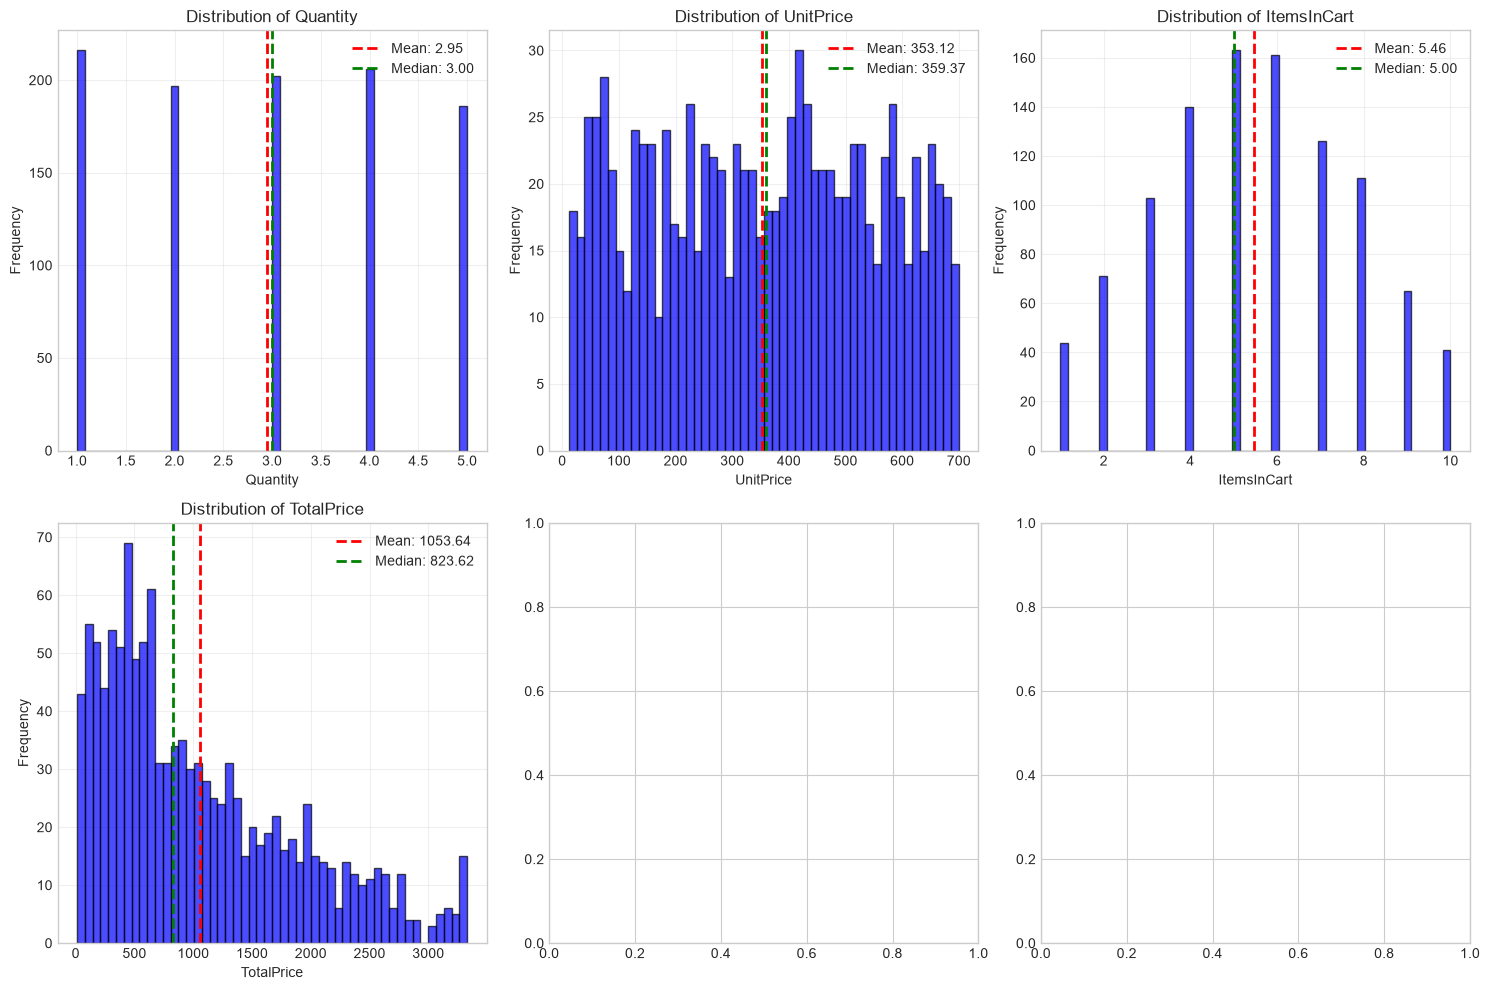


✅ Visualization complete!


In [24]:
# ============================================
# VISUALIZATION - Saving to Your Outputs Folder
# ============================================

print("="*60)
print("CREATING AND SAVING VISUALIZATIONS")
print("="*60)

# Get columns that actually exist and have data
numeric_cols = df_winsor.select_dtypes(include=[np.number]).columns.tolist()

# Remove target columns
for col in ['Class', 'DEFAULT']:
    if col in numeric_cols:
        numeric_cols.remove(col)

# Take first 6 columns that have data
plot_cols = []
for col in numeric_cols:
    if df_winsor[col].count() > 0:
        plot_cols.append(col)
    if len(plot_cols) >= 6:
        break

print(f"Plotting these columns: {plot_cols}")

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(plot_cols):
    ax = axes.flatten()[i]
    
    # Get data
    data = df_winsor[col].dropna()
    
    # Plot histogram
    ax.hist(data, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)
    
    # Add mean and median lines
    ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {data.median():.2f}')
    ax.legend()

plt.tight_layout()

# SAVE TO YOUR EXACT PATH
plt.savefig('C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/distributions.png', dpi=300, bbox_inches='tight')
print("✅ Saved to: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/distributions.png")

plt.show()

print("\n✅ Visualization complete!")

# Saving Work

In [31]:
print("="*60)
print("EXPORTING YOUR WORK TO CORRECT PATHS")
print("="*60)

import os

# YOUR CORRECT PATHS
base_path = 'C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship'
data_path = base_path + '/data'
outputs_path = base_path + '/outputs'

# Create folders if they don't exist
if not os.path.exists(data_path):
    os.makedirs(data_path)
    print(f"✅ Created: {data_path}")

if not os.path.exists(outputs_path):
    os.makedirs(outputs_path)
    print(f"✅ Created: {outputs_path}")

# 1. Save cleaned data
df_winsor.to_csv(data_path + '/cleaned_credit_data.csv', index=False)
print(f"✅ Saved: {data_path}/cleaned_credit_data.csv")

# 2. Save column information
columns_info = pd.DataFrame({
    'Column': df_winsor.columns,
    'Data_Type': df_winsor.dtypes.values,
    'Non_Null': df_winsor.notnull().sum().values,
    'Unique': df_winsor.nunique().values
})
columns_info.to_csv(outputs_path + '/column_info.csv', index=False)
print(f"✅ Saved: {outputs_path}/column_info.csv")

print("\n" + "="*60)
print("📁 FILES SAVED TO:")
print("="*60)
print(f"📊 Data:     {data_path}/cleaned_credit_data.csv")
print(f"📋 Info:     {outputs_path}/column_info.csv")

EXPORTING YOUR WORK TO CORRECT PATHS
✅ Saved: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/data/cleaned_credit_data.csv
✅ Saved: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/column_info.csv

📁 FILES SAVED TO:
📊 Data:     C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/data/cleaned_credit_data.csv
📋 Info:     C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/column_info.csv


# Verifying all files exist

In [33]:
import os

print("="*60)
print("VERIFYING SAVED FILES")
print("="*60)

# YOUR CORRECT PATHS
base_path = 'C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship'
data_path = base_path + '/data'
outputs_path = base_path + '/outputs'

files_to_check = [
    (data_path + '/cleaned_credit_data.csv', 'Cleaned Data'),
    (outputs_path + '/column_info.csv', 'Column Information'),
    (outputs_path + '/distributions.png', 'Main Visualization')
]

all_exist = True
for file_path, description in files_to_check:
    if os.path.exists(file_path):
        size = os.path.getsize(file_path) / 1024
        if file_path.endswith('.csv'):
            import pandas as pd
            df_check = pd.read_csv(file_path)
            print(f"✅ {description}: {file_path} ({len(df_check):,} rows, {size:.1f} KB)")
        else:
            print(f"✅ {description}: {file_path} ({size:.1f} KB)")
    else:
        print(f"❌ {description}: {file_path} - NOT FOUND")
        all_exist = False

if all_exist:
    print("\n" + "="*60)
    print("🎉 ALL FILES ARE READY!")
    print("="*60)
else:
    print("\n⚠️ Some files are missing. Run STEP 1 first.")

VERIFYING SAVED FILES
✅ Cleaned Data: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/data/cleaned_credit_data.csv (1,200 rows, 24.8 KB)
✅ Column Information: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/column_info.csv (4 rows, 0.1 KB)
✅ Main Visualization: C:/Users/Sunrise Computer/Desktop/DecodeLabs_Internship/outputs/distributions.png (280.6 KB)

🎉 ALL FILES ARE READY!
